In [ ]:
import os, random, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from itertools import combinations
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Dense, Flatten, Dropout,
    Lambda, GlobalAveragePooling2D, BatchNormalization, Layer
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("tushar5harma/plant-village-dataset-updated")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plant-village-dataset-updated' dataset.
Path to dataset files: /kaggle/input/plant-village-dataset-updated


In [ ]:
BASE_DIR   = path

all_train_data_dirs = []
all_val_data_dirs = []
all_test_data_dirs = []
all_class_names = set()

for plant_type_folder in sorted(os.listdir(BASE_DIR)):
    plant_type_path = os.path.join(BASE_DIR, plant_type_folder)
    if os.path.isdir(plant_type_path):
        train_path_for_plant = os.path.join(plant_type_path, 'Train')
        val_path_for_plant = os.path.join(plant_type_path, 'Val')
        test_path_for_plant = os.path.join(plant_type_path, 'Test')

        if os.path.isdir(train_path_for_plant):
            all_train_data_dirs.append(train_path_for_plant)
            for disease_name_folder in sorted(os.listdir(train_path_for_plant)):
                if os.path.isdir(os.path.join(train_path_for_plant, disease_name_folder)):
                    all_class_names.add(disease_name_folder)
        if os.path.isdir(val_path_for_plant):
            all_val_data_dirs.append(val_path_for_plant)
        if os.path.isdir(test_path_for_plant):
            all_test_data_dirs.append(test_path_for_plant)

TRAIN_DIR = BASE_DIR
VAL_DIR = BASE_DIR
TEST_DIR = BASE_DIR

IMG_SIZE    = 224
BATCH_SIZE  = 32
EMBED_DIM   = 128
MARGIN      = 1.0
EPOCHS      = 30
LR          = 1e-4

CLASS_NAMES = sorted(list(all_class_names))
N_CLASSES   = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

print(f'Jumlah kelas : {N_CLASSES}')
print(f'Embed dim    : {EMBED_DIM}')
print(f'Margin       : {MARGIN}')


Jumlah kelas : 16
Embed dim    : 128
Margin       : 1.0


## Dataset

In [ ]:
def build_class_dict(data_dir):
    class_dict = {}
    for cls in sorted(os.listdir(data_dir)):
        cls_path = os.path.join(data_dir, cls)
        if os.path.isdir(cls_path):
            imgs = [os.path.join(cls_path, f)
                    for f in os.listdir(cls_path)
                    if f.lower().endswith(('.jpg','.jpeg','.png'))]
            if imgs:
                class_dict[cls] = imgs
    return class_dict

combined_train_class_dict = {}
combined_val_class_dict = {}
combined_test_class_dict = {}

for train_data_dir in all_train_data_dirs:
    current_plant_train_dict = build_class_dict(train_data_dir)
    combined_train_class_dict.update(current_plant_train_dict)

for val_data_dir in all_val_data_dirs:
    current_plant_val_dict = build_class_dict(val_data_dir)
    combined_val_class_dict.update(current_plant_val_dict)

for test_data_dir in all_test_data_dirs:
    current_plant_test_dict = build_class_dict(test_data_dir)
    combined_test_class_dict.update(current_plant_test_dict)

train_class_dict = combined_train_class_dict
val_class_dict = combined_val_class_dict
test_class_dict = combined_test_class_dict

total_train = sum(len(v) for v in train_class_dict.values())
print(f'Total gambar train : {total_train}')
print(f'Contoh kelas       : {list(train_class_dict.keys())[:3]}')

Total gambar train : 29325
Contoh kelas       : ['Apple Scab', 'Black Rot', 'Cedar Apple Rust']


## Arsitektur Siamese
### Siamese CNN dengan Contrastive Loss

In [ ]:
def build_embedding_network_tf(input_shape=(224, 224, 3), embed_dim=128):
    base = MobileNetV2(weights='imagenet', include_top=False,
                       input_shape=input_shape)
    # Freeze backbone
    for layer in base.layers[:-20]:
        layer.trainable = False

    inputs = Input(shape=input_shape)
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    # L2-normalized embedding
    embeddings = Dense(embed_dim)(x)
    embeddings = Lambda(lambda t: K.l2_normalize(t, axis=1),
                        name='l2_normalize')(embeddings)
    return Model(inputs, embeddings, name='EmbeddingNet')


def build_siamese_tf(input_shape=(224, 224, 3), embed_dim=128):
    embedding_net = build_embedding_network_tf(input_shape, embed_dim)

    input_a = Input(shape=input_shape, name='input_A')
    input_b = Input(shape=input_shape, name='input_B')

    embed_a = embedding_net(input_a)   # shared weights
    embed_b = embedding_net(input_b)   # shared weights

    # Euclidean distance antara dua embedding
    distance = Lambda(
        lambda tensors: K.sqrt(K.sum(K.square(tensors[0] - tensors[1]), axis=1, keepdims=True)),
        name='euclidean_distance'
    )([embed_a, embed_b])

    siamese_model = Model([input_a, input_b], distance, name='SiameseNetwork')
    return siamese_model, embedding_net


siamese_tf, embed_net_tf = build_siamese_tf(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    embed_dim=EMBED_DIM
)

print(f'Siamese TF Total params    : {siamese_tf.count_params():,}')
embed_net_tf.summary()

Siamese TF Total params    : 2,619,840


Model: "EmbeddingNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalize (Lambda)           │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,840 (9.99 MB)

 Trainable params: 1,567,424 (5.98 MB)

 Non-trainable params: 1,052,416 (4.01 MB)

### Contrastive Loss

In [ ]:
def contrastive_loss_tf(y_true, y_pred, margin=MARGIN):
    y_true = tf.cast(y_true, tf.float32)
    d      = tf.squeeze(y_pred, axis=1)
    loss   = (y_true * tf.square(d) +
              (1 - y_true) * tf.square(tf.maximum(margin - d, 0)))
    return tf.reduce_mean(loss)


def contrastive_accuracy_tf(y_true, y_pred, threshold=0.5):
    y_true = tf.cast(y_true, tf.float32)
    pred_similar = tf.cast(tf.less(tf.squeeze(y_pred, 1), threshold), tf.float32)
    return tf.reduce_mean(tf.cast(tf.equal(y_true, pred_similar), tf.float32))


siamese_tf.compile(
    optimizer=Adam(LR),
    loss=contrastive_loss_tf,
    metrics=[contrastive_accuracy_tf]
)
print('Siamese TF compiled!')

Siamese TF compiled!


### Siamese Dataset Generator

In [ ]:
IMG_SIZE = 224

import numpy as np
import os
import kagglehub
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array

path = kagglehub.dataset_download("tushar5harma/plant-village-dataset-updated")
BASE_DIR = path

all_train_data_dirs = []
all_val_data_dirs = []
all_test_data_dirs = []

for plant_type_folder in sorted(os.listdir(BASE_DIR)):
    plant_type_path = os.path.join(BASE_DIR, plant_type_folder)
    if os.path.isdir(plant_type_path):
        train_path_for_plant = os.path.join(plant_type_path, 'Train')
        val_path_for_plant = os.path.join(plant_type_path, 'Val')
        test_path_for_plant = os.path.join(plant_type_path, 'Test')

        if os.path.isdir(train_path_for_plant):
            all_train_data_dirs.append(train_path_for_plant)
        if os.path.isdir(val_path_for_plant):
            all_val_data_dirs.append(val_path_for_plant)
        if os.path.isdir(test_path_for_plant):
            all_test_data_dirs.append(test_path_for_plant)

def build_class_dict(data_dir):
    class_dict = {}
    for cls in sorted(os.listdir(data_dir)):
        cls_path = os.path.join(data_dir, cls)
        if os.path.isdir(cls_path):
            imgs = [os.path.join(cls_path, f)
                    for f in os.listdir(cls_path)
                    if f.lower().endswith(('.jpg','.jpeg','.png'))]
            if imgs:
                class_dict[cls] = imgs
    return class_dict

combined_train_class_dict = {}
combined_val_class_dict = {}

if 'all_train_data_dirs' in globals():
    for train_data_dir in all_train_data_dirs:
        current_plant_train_dict = build_class_dict(train_data_dir)
        combined_train_class_dict.update(current_plant_train_dict)

if 'all_val_data_dirs' in globals():
    for val_data_dir in all_val_data_dirs:
        current_plant_val_dict = build_class_dict(val_data_dir)
        combined_val_class_dict.update(current_plant_val_dict)

train_class_dict = combined_train_class_dict
val_class_dict = combined_val_class_dict

def load_image_tf(path, img_size=IMG_SIZE):
    img = load_img(path, target_size=(img_size, img_size))
    arr = img_to_array(img) / 255.0
    return arr


def generate_siamese_pairs_tf(class_dict, n_pairs_per_class=100, img_size=IMG_SIZE):
    pairs_a, pairs_b, labels = [], [], []
    classes = list(class_dict.keys())

    for cls in classes:
        imgs = class_dict[cls]
        if len(imgs) < 2:
            continue
        for _ in range(n_pairs_per_class):
            a, b = random.sample(imgs, 2)
            pairs_a.append(load_image_tf(a, img_size))
            pairs_b.append(load_image_tf(b, img_size))
            labels.append(1.0)

    for _ in range(len(classes) * n_pairs_per_class):
        cls_a, cls_b = random.sample(classes, 2)
        a = random.choice(class_dict[cls_a])
        b = random.choice(class_dict[cls_b])
        pairs_a.append(load_image_tf(a, img_size))
        pairs_b.append(load_image_tf(b, img_size))
        labels.append(0.0)

    idx = np.arange(len(labels))
    np.random.shuffle(idx)
    return (np.array(pairs_a)[idx],
            np.array(pairs_b)[idx],
            np.array(labels)[idx])


print('Membuat pasangan gambar untuk training...')
X_a_tr, X_b_tr, y_tr = generate_siamese_pairs_tf(train_class_dict, n_pairs_per_class=50)
X_a_vl, X_b_vl, y_vl = generate_siamese_pairs_tf(val_class_dict,   n_pairs_per_class=20)

print(f'Train pairs : {len(y_tr)} | Positive: {int(y_tr.sum())} | Negative: {int((1-y_tr).sum())}')
print(f'Val pairs   : {len(y_vl)}')

Using Colab cache for faster access to the 'plant-village-dataset-updated' dataset.
Membuat pasangan gambar untuk training...
Train pairs : 1600 | Positive: 800 | Negative: 800
Val pairs   : 640


## Training Siamese Network

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import time

callbacks_siamese = [
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_siamese_tf.h5', monitor='val_contrastive_accuracy_tf',
                    save_best_only=True, verbose=0, mode='max')
]

print('Training Siamese Network (TensorFlow)...')
t0 = time.time()
history_siamese_tf = siamese_tf.fit(
    [X_a_tr, X_b_tr], y_tr,
    validation_data=([X_a_vl, X_b_vl], y_vl),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks_siamese,
    verbose=1
)
print(f'Selesai dalam {time.time()-t0:.1f}s')

Training Siamese Network (TensorFlow)...
Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - contrastive_accuracy_tf: 0.4940 - loss: 0.9423

50/50 ━━━━━━━━━━━━━━━━━━━━ 233s 4s/step - contrastive_accuracy_tf: 0.5000 - loss: 0.9027 - val_contrastive_accuracy_tf: 0.5063 - val_loss: 0.5134
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - contrastive_accuracy_tf: 0.5159 - loss: 0.7424

50/50 ━━━━━━━━━━━━━━━━━━━━ 232s 5s/step - contrastive_accuracy_tf: 0.5000 - loss: 0.7338 - val_contrastive_accuracy_tf: 0.5844 - val_loss: 0.5829
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - contrastive_accuracy_tf: 0.5025 - loss: 0.6646

50/50 ━━━━━━━━━━━━━━━━━━━━ 228s 5s/step - contrastive_accuracy_tf: 0.5025 - loss: 0.6523 - val_contrastive_accuracy_tf: 0.6406 - val_loss: 0.6058
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - contrastive_accuracy_tf: 0.5111 - loss: 0.6064

50/50 ━━━━━━━━━━━━━━━━━━━━ 193s 4s/step - contrastive_accuracy_tf: 0.5169 - loss: 0.6010 - val_contrastive_accuracy_tf: 0.6562 - val_loss: 0.5935
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - contrastive_accuracy_tf: 0.5293 - loss: 0.5590

50/50 ━━━━━━━━━━━━━━━━━━━━ 241s 5s/step - contrastive_accuracy_tf: 0.5288 - loss: 0.5643 - val_contrastive_accuracy_tf: 0.6734 - val_loss: 0.5675
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - contrastive_accuracy_tf: 0.5388 - loss: 0.5217

50/50 ━━━━━━━━━━━━━━━━━━━━ 231s 5s/step - contrastive_accuracy_tf: 0.5456 - loss: 0.5197 - val_contrastive_accuracy_tf: 0.7094 - val_loss: 0.5408
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 228s 5s/step - contrastive_accuracy_tf: 0.5456 - loss: 0.4931 - val_contrastive_accuracy_tf: 0.7016 - val_loss: 0.5383
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 203s 4s/step - contrastive_accuracy_tf: 0.5537 - loss: 0.4584 - val_contrastive_accuracy_tf: 0.6484 - val_loss: 0.5542
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 1.
Selesai dalam 1851.7s


## Klasifikasi Multi-Class dengan Prototype

In [ ]:
import numpy as np
import tensorflow as tf
from PIL import Image
import os
import random

def load_image_tf(path, img_size=IMG_SIZE):
    img = Image.open(path).convert('RGB').resize((img_size, img_size))
    arr = np.array(img) / 255.0
    return arr

def compute_class_prototypes_tf(model_embedding, class_dict, max_per_class=50, img_size=IMG_SIZE):
    prototypes = {}
    print('Menghitung class prototypes...')
    for cls, img_paths in class_dict.items():
        embeddings = []
        for path in img_paths[:max_per_class]:
            img_array = load_image_tf(path, img_size)
            emb = model_embedding.predict(np.expand_dims(img_array, axis=0), verbose=0)[0]
            embeddings.append(emb)
        if embeddings:
            prototypes[cls] = np.mean(embeddings, axis=0)
    print(f'Prototypes siap untuk {len(prototypes)} kelas')
    return prototypes


def classify_by_prototype_tf(model_embedding, img_path, prototypes, img_size=IMG_SIZE):
    query_img_array = load_image_tf(img_path, img_size)
    query_emb = model_embedding.predict(np.expand_dims(query_img_array, axis=0), verbose=0)[0]

    distances = {}
    for cls, proto in prototypes.items():
        distances[cls] = np.linalg.norm(query_emb - proto)

    return min(distances, key=distances.get), distances


def evaluate_prototype_classifier_tf(model_embedding, class_dict, prototypes,
                                      max_per_class=30, img_size=IMG_SIZE):
    y_true, y_pred = [], []
    classes = sorted(list(class_dict.keys()))
    cls_to_idx = {c: i for i, c in enumerate(classes)}

    print('Evaluasi prototype classifier pada test set...')
    for cls in classes:
        img_paths = class_dict.get(cls, [])
        for path in img_paths[:max_per_class]:
            pred_cls, _ = classify_by_prototype_tf(
                model_embedding, path, prototypes, img_size)
            y_true.append(cls_to_idx[cls])
            y_pred.append(cls_to_idx.get(pred_cls, -1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = np.mean(y_true == y_pred)
    print(f'Prototype Classifier Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    return y_true, y_pred, acc

class_prototypes = compute_class_prototypes_tf(
    embed_net_tf, train_class_dict, max_per_class=30, img_size=IMG_SIZE)

y_true_proto, y_pred_proto, proto_acc = evaluate_prototype_classifier_tf(
    embed_net_tf, test_class_dict, class_prototypes,
    max_per_class=20, img_size=IMG_SIZE)

Menghitung class prototypes...
Prototypes siap untuk 16 kelas
Evaluasi prototype classifier pada test set...
Prototype Classifier Accuracy: 0.7281 (72.81%)


## Visualisasi Embedding (t-SNE)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_7026/197705200.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab20', n_classes)


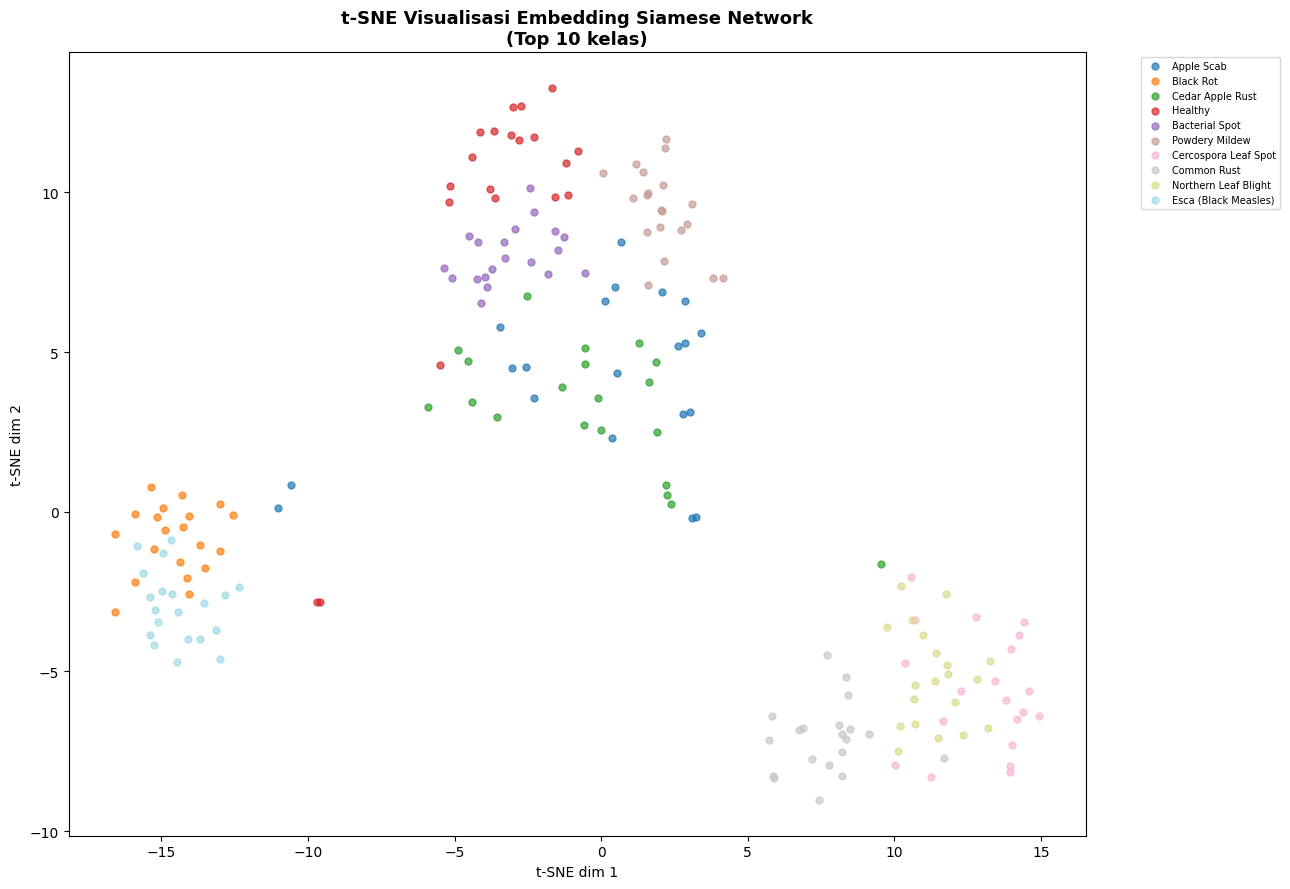

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image
import random

SEED = 42

def load_image_tf(path, img_size=IMG_SIZE):
    img = Image.open(path).convert('RGB').resize((img_size, img_size))
    arr = np.array(img) / 255.0
    return arr

def visualize_embeddings_tsne(model_embedding, class_dict,
                               n_classes=10, n_per_class=30, img_size=IMG_SIZE):
    all_embeds, all_labels, all_class_names = [], [], []

    classes = list(class_dict.keys())[:n_classes]
    for cls in classes:
        if cls in class_dict and len(class_dict[cls]) > 0:
            for path in class_dict[cls][:n_per_class]:
                img_array = load_image_tf(path, img_size)
                emb = model_embedding.predict(np.expand_dims(img_array, axis=0), verbose=0)[0]
                all_embeds.append(emb)
                all_labels.append(classes.index(cls))
                all_class_names.append(cls)
        else:
            print(f"Warning: Class '{cls}' not found or has no images in class_dict.")

    X = np.array(all_embeds)
    labels = np.array(all_labels)

    if len(X) == 0:
        print("No embeddings generated. Cannot perform t-SNE.")
        return

    perplexity_val = min(30, max(1, len(X) - 1))
    tsne = TSNE(n_components=2, perplexity=perplexity_val, random_state=SEED, n_iter=1000)
    X_2d = tsne.fit_transform(X)

    fig, ax = plt.subplots(figsize=(13, 9))
    palette = plt.cm.get_cmap('tab20', n_classes)
    for i, cls in enumerate(classes):
        mask = labels == i
        if np.any(mask):
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                       c=[palette(i)], label=cls[:25], alpha=0.7, s=25)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
    ax.set_title(f't-SNE Visualisasi Embedding Siamese Network\n(Top {n_classes} kelas)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
    plt.tight_layout()
    plt.savefig('siamese_tsne.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_embeddings_tsne(embed_net_tf, test_class_dict,
                           n_classes=min(10, N_CLASSES), n_per_class=20, img_size=IMG_SIZE)

## Visualisasi Training & Evaluasi Lengkap

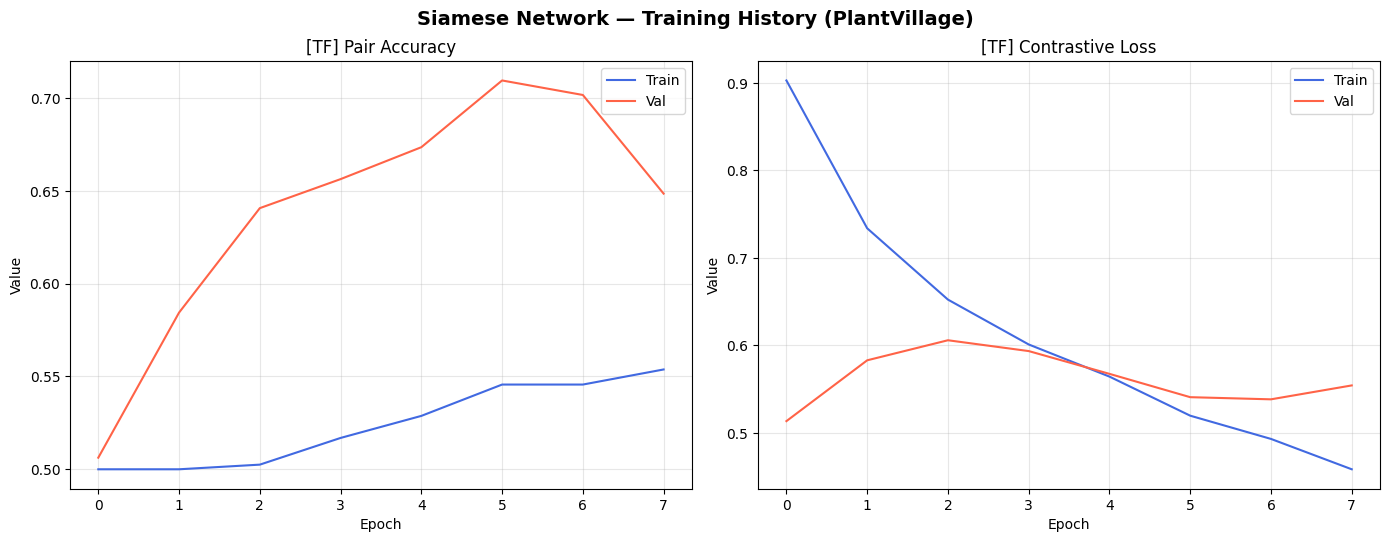

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Siamese Network — Training History (PlantVillage)', fontsize=14, fontweight='bold')

axes[0,0].plot(history_siamese_tf.history['contrastive_accuracy_tf'], label='Train', color='royalblue')
axes[0,0].plot(history_siamese_tf.history['val_contrastive_accuracy_tf'], label='Val', color='tomato')
axes[0,0].set_title('[TF] Pair Accuracy'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(history_siamese_tf.history['loss'], label='Train', color='royalblue')
axes[0,1].plot(history_siamese_tf.history['val_loss'], label='Val', color='tomato')
axes[0,1].set_title('[TF] Contrastive Loss'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

fig.delaxes(axes[1,0])
fig.delaxes(axes[1,1])

for ax in axes.flat:
    ax.set_xlabel('Epoch'); ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('siamese_training_history.png', dpi=150)
plt.show()

In [ ]:
classes = list(test_class_dict.keys())
print('='*60)
print('Classification Report — Siamese Prototype Classifier (PT)')
print('='*60)
print(classification_report(y_true_proto, y_pred_proto,
                             target_names=classes, zero_division=0))

Classification Report — Siamese Prototype Classifier (PT)
                        precision    recall  f1-score   support

            Apple Scab       0.64      0.35      0.45        20
             Black Rot       0.64      0.90      0.75        20
      Cedar Apple Rust       0.81      0.85      0.83        20
               Healthy       0.59      0.65      0.62        20
        Bacterial Spot       0.75      0.75      0.75        20
        Powdery Mildew       0.95      0.90      0.92        20
  Cercospora Leaf Spot       0.50      0.55      0.52        20
          Common Rust        0.85      0.85      0.85        20
  Northern Leaf Blight       0.88      0.70      0.78        20
  Esca (Black Measles)       0.53      0.40      0.46        20
           Leaf Blight       0.78      0.90      0.84        20
          Early Blight       0.88      0.75      0.81        20
           Late Blight       0.73      0.80      0.76        20
           Leaf Scorch       0.76      0.95  

## Hasil Akhir

In [ ]:
try:
    df_tl = pd.read_csv('transfer_learning_results.csv')
except FileNotFoundError:
    df_tl = pd.DataFrame(columns=['Model','Framework','Test Loss','Test Acc'])

siamese_row = pd.DataFrame([{
    'Model': 'Siamese Network (Prototype)',
    'Framework': 'PyTorch',
    'Test Loss': '-',
    'Test Acc': round(proto_acc, 4)
}])

df_all = pd.concat([df_tl, siamese_row], ignore_index=True)
df_all['Test Acc %'] = df_all['Test Acc'].apply(
    lambda x: f"{float(x)*100:.2f}%" if str(x) != '-' else '-')

print('\n' + '='*70)
print('    RINGKASAN AKHIR — Simple CNN vs Transfer Learning vs Siamese')
print('='*70)
print(df_all.to_string(index=False))
print('='*70)

df_all.to_csv('all_models_final_results.csv', index=False)
print('\nFile tersimpan: all_models_final_results.csv')
print('Grafik        : siamese_training_history.png')
print('t-SNE         : siamese_tsne.png')


    RINGKASAN AKHIR — Simple CNN vs Transfer Learning vs Siamese
                      Model Framework Test Loss  Test Acc Test Acc %
Siamese Network (Prototype)   PyTorch         -    0.7281     72.81%

File tersimpan: all_models_final_results.csv
Grafik        : siamese_training_history.png
t-SNE         : siamese_tsne.png


/tmp/ipykernel_7026/636669572.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([df_tl, siamese_row], ignore_index=True)
